In [16]:
import matplotlib.pyplot as plt

In [17]:
import pandas as pd

def alphaCalc(N):
    return 2 / (N + 1)

data = pd.read_csv('Data.csv')


In [18]:
def subArrays(arr1, arr2):
    resultArr = []
    length = len(arr1)
    if len(arr2)<length:
        length = len(arr2)
    for i in range(0, length):
        resultArr.append(arr1[i]-arr2[i])
    return resultArr

In [19]:
def EMA_element_calc(data, N, id_of_curr_elem):
    OneMinusAlpha=1-alphaCalc(N)
    emaNumerator = data[id_of_curr_elem]
    emaDenominator =1
    for i in range(1, min(N, id_of_curr_elem+1)):
        emaNumerator+=(OneMinusAlpha**i)*data[id_of_curr_elem-i]
        emaDenominator+=OneMinusAlpha**i
    return emaNumerator/emaDenominator


In [20]:
def EMA_calc(data, N):
    EMAs_array = []
    for i in range(0,len(data)): #through all numbers
        emaElem = EMA_element_calc(data, N, i)
        EMAs_array.append(emaElem)
    return EMAs_array


In [21]:
def toFloats(array):
    float_array = []
    for i in array:
        item = float(i.replace(',',''))
        float_array.append(item)
    return float_array

In [22]:
def intersectionPoints(MACD, SIGNAL): #TODO correct to not equalizing
    intersection = []
    buy = []
    sell = []
    for i in range(1, len(MACD)-1): #skip first because there is no way to analyse if it would be buy or sell
        # if abs(MACD[i]-SIGNAL[i])*100<1 and MACD[i]-SIGNAL[i]<0:
        if MACD[i-1] < SIGNAL[i-1] and MACD[i] > SIGNAL[i]:
            intersection.append(i) #add id in MACD array to intersection array
            sell.append((i,MACD[i]))
        # elif (abs(MACD[i]-SIGNAL[i]))*100<1 and MACD[i]-SIGNAL[i]>0:
        elif MACD[i-1] > SIGNAL[i-1] and MACD[i] < SIGNAL[i]:
            intersection.append(i)
            buy.append((i,MACD[i]))       
    return intersection, buy, sell

In [23]:
data_from_csv = pd.read_csv('Data.csv')
data_for_calc = data_from_csv['Close']
data_for_calc = data_for_calc.tolist()
data_for_calc = data_for_calc[::-1]

In [24]:
#data_for_calc = toFloats(data_for_calc)


In [25]:
EMA12 = EMA_calc(data_for_calc, 12)
EMA26 = EMA_calc(data_for_calc,26)
MACD = subArrays(EMA12,EMA26)
SIGNAL = EMA_calc(MACD,9)

In [26]:
intersectPoints, buyArray, sellArray = intersectionPoints(MACD, SIGNAL)

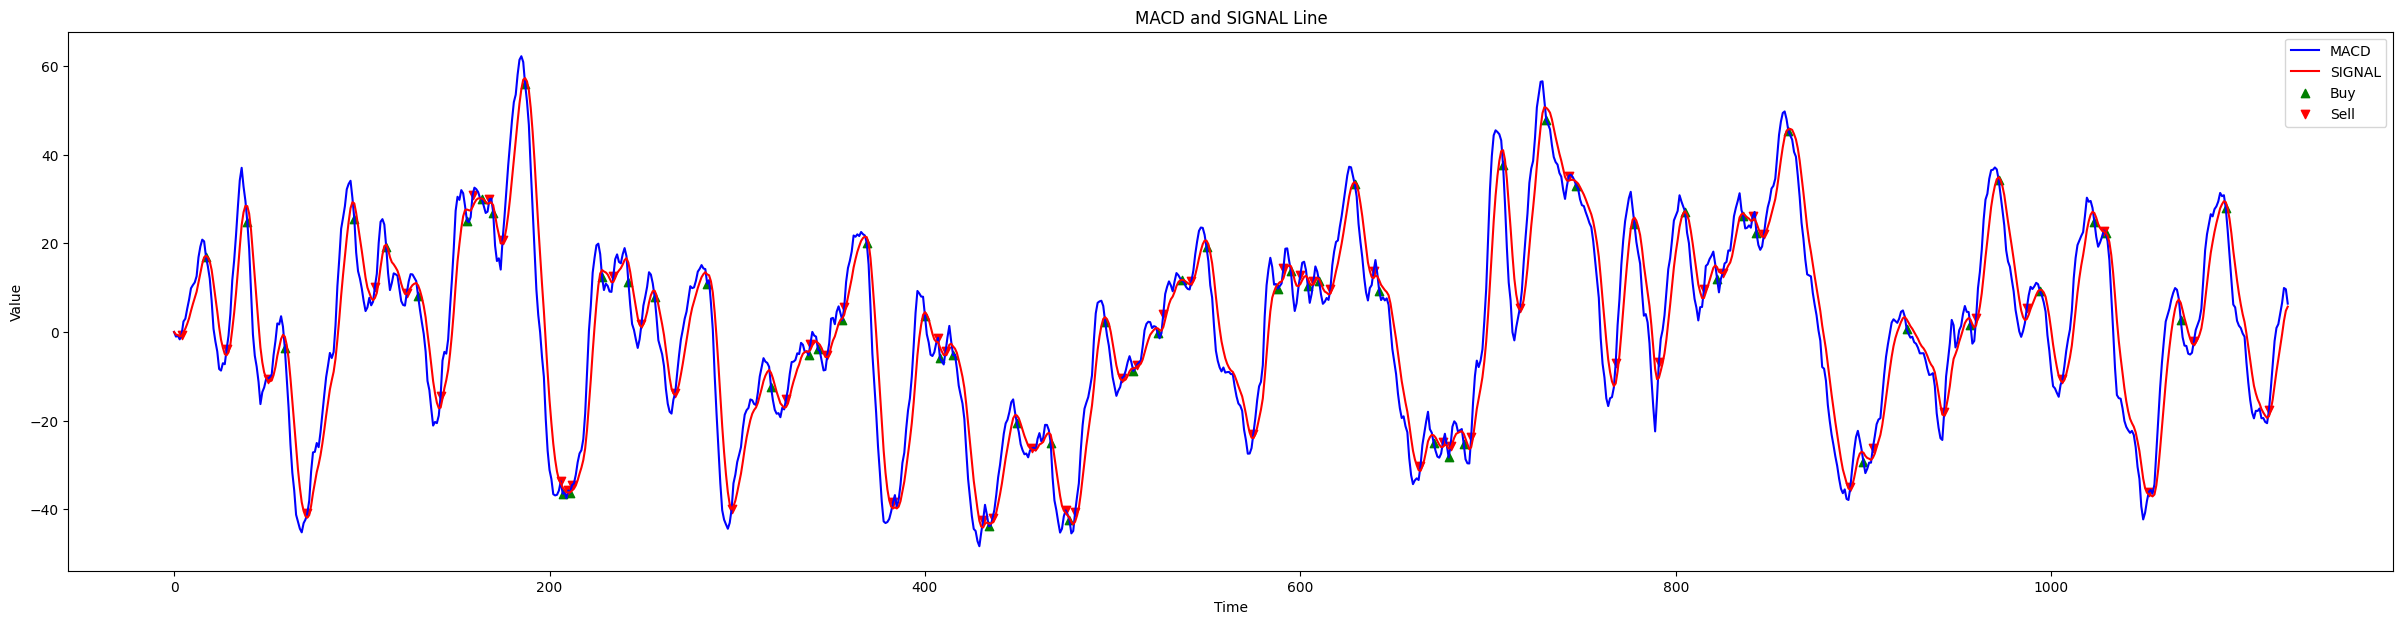

In [27]:
plt.figure(figsize=(30,7))
plt.plot(MACD, label='MACD', color='blue')
plt.plot(SIGNAL, label='SIGNAL', color='red')

buyPoints = [point[0] for point in buyArray]
buyValues = [point[1] for point in buyArray]
sellPoints = [point[0] for point in sellArray]
sellValues = [point[1] for point in sellArray]


plt.scatter(buyPoints, buyValues, color='green', marker='^', label='Buy')
plt.scatter(sellPoints, sellValues, color='red', marker='v', label='Sell')

plt.legend(loc='upper right')
plt.title('MACD and SIGNAL Line')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()


ValueError: x and y must be the same size

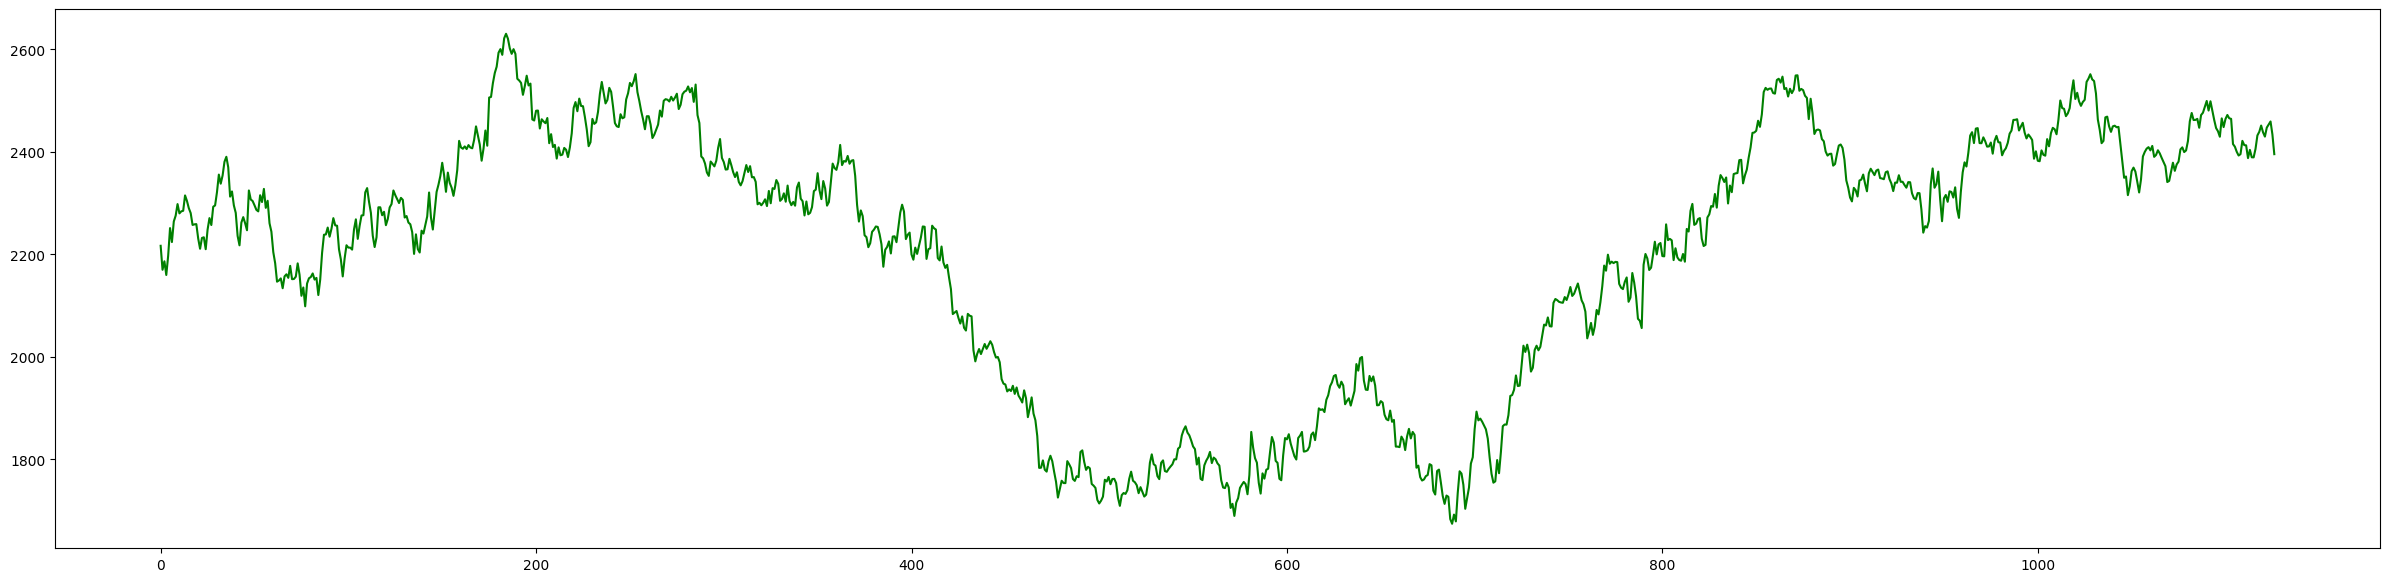

In [ ]:
plt.figure(figsize=(30,7))
plt.plot(data_for_calc,label='WIG20 value', color='green')

buyPoints = [point[0] for point in buyArray]
buyValues = [point for point in data_for_calc] #TODO function to get array containing elements from another array (where indexes in 2nd arr = value in 1st arr)
sellPoints = [point[0] for point in sellArray]
sellValues = [point for point in data_for_calc]

plt.scatter(buyPoints, buyValues, color='green', marker='^', label='Buy')
plt.scatter(sellPoints, sellValues, color='red', marker='v', label='Sell')
plt.legend(loc='upper right')

plt.title('WIG20 value')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()